In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]) # years
y_train = np.array([42.0, 47.0, 56.0, 58.0, 66.0, 71.0, 78.0, 81.0, 89.0, 95.0]) #salary in 1000s

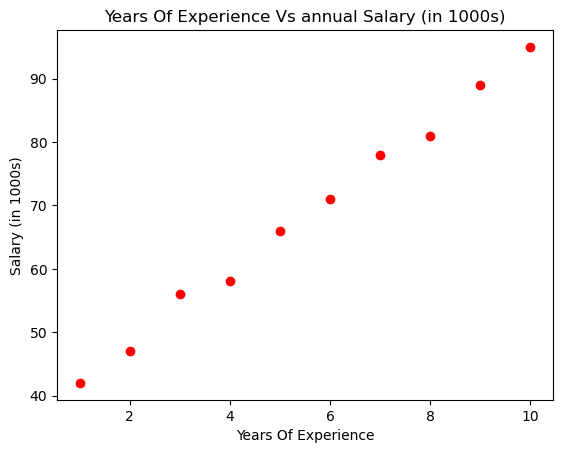

In [4]:
# plotting on graph 
plt.scatter(x_train, y_train, marker = 'o', c='r')
plt.title("Years Of Experience Vs annual Salary (in 1000s)")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary (in 1000s)")
plt.show()

In [5]:
def compute_cost(x, y, w, b):
    cost = 0;
    m = len(x)
    for i in range(m):
        cost += (((x[i] * w) + b) - y[i]) ** 2
    cost /= 2*m

    return cost

In [38]:
def compute_gradient(x, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = len(x)
    for i in range(m):
        dj_dw += (((x[i] * w) + b) - y[i]) * x[i]
        dj_db += (((x[i] * w) + b) - y[i])

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [39]:
def gradient_descent(x, y, w_init, b_init, alpha, iterations, threshold):
    cost_history = []
    w = w_init
    b = b_init
    cost_history.append(compute_cost(x, y, w, b))

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)
        cost_history.append(compute_cost(x, y, w, b))

        if (i % math.ceil(iterations /10)) == 0:
            print(f"cost: {cost_history[-1]}, w: {w:.3f}, b:{b:.3f}, dj_dw:{dj_dw:.3f}, dj_db:{dj_db:.3f}")
        if abs(dj_dw) < threshold and abs(dj_db) < threshold:
            print(dj_dw)
            break

    return cost_history, w, b

In [79]:
w = 0
b = 0
iterations = 1000
threshold = 0.02
alphas = [0.05, 0.03, 0.001]

cost_history, final_w, final_b = gradient_descent(x_train, y_train, w, b, alphas[0], iterations, threshold)


cost: 2306.9407062500004, w: 21.185, b:3.415, dj_dw:-423.700, dj_db:-68.300
cost: 17.573466988921886, w: 7.822, b:24.352, dj_dw:-11.075, dj_db:-4.180
cost: 2.5338358439100737, w: 6.429, b:32.107, dj_dw:-0.181, dj_db:-0.927
cost: 0.9022911429199677, w: 6.032, b:34.819, dj_dw:0.036, dj_db:-0.308
cost: 0.7047960004548373, w: 5.897, b:35.763, dj_dw:0.015, dj_db:-0.107
cost: 0.6808730143769002, w: 5.849, b:36.091, dj_dw:0.005, dj_db:-0.037
0.002869281705945781


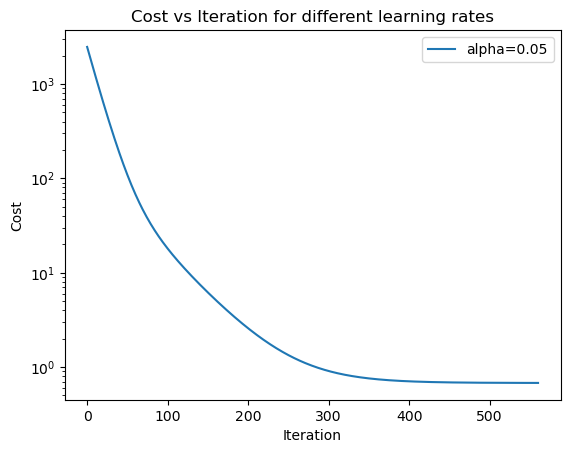

In [80]:
plt.plot(cost_history, label='alpha=0.05')
plt.yscale('log')
plt.title("Cost vs Iteration for different learning rates")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [81]:
def linear_regression(x, w, b):
    y_predictions = []
    m = len(x)

    for i in range(m):
        predict = x[i] * w + b
        y_predictions.append(predict)

    return y_predictions


        

In [83]:
# making predictions
y_hat = linear_regression(x_train, final_w, final_b)

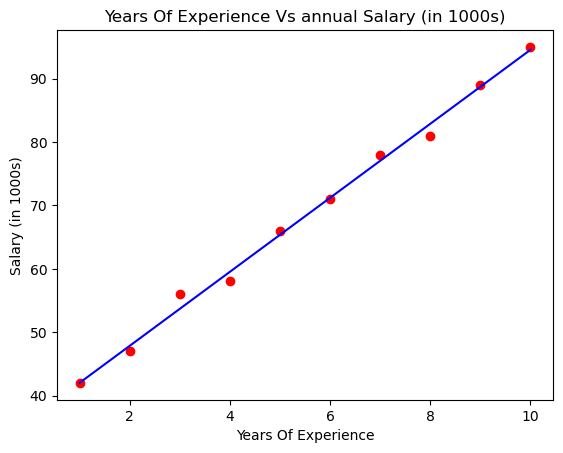

In [84]:
# plotting on graph 
plt.scatter(x_train, y_train, marker = 'o', c='r')
plt.plot(x_train, y_hat, c='b')
plt.title("Years Of Experience Vs annual Salary (in 1000s)")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary (in 1000s)")
plt.show()

In [88]:
print(f"Salary at year 6.5 is ${(((6.5 * final_w) + b)*1000):.2f}")

Salary at year 6.5 is $37945.44
